# ARIN 5204:  Homework 3

**Instructions:** Complete all code blanks marked with **TODO** comments.

In this assignment, you will implement and compare several policy gradient and actor-critic algorithms on two classic control problems:

- **Atari Pong** using:
  - REINFORCE
  - Actor-Critic
  - Proximal Policy Optimization (PPO)

- **Pendulum-v1** using:
  - Deep Deterministic Policy Gradient (DDPG)



In [ ]:
import numpy as np
import random
from collections import deque, namedtuple
import matplotlib.pyplot as plt
import ale_py
import gymnasium as gym
gym.register_envs(ale_py)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from torch.distributions.normal import Normal

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)


Using device: cuda


In [ ]:
def plot_returns(returns_dict, title="Episode Returns", smoothing_window=10):
    """
    returns_dict: dict[name -> list of episode returns]
    """
    plt.figure(figsize=(8, 5))
    for label, returns in returns_dict.items():
        if len(returns) == 0:
            continue
        returns = np.array(returns, dtype=np.float32)
        if len(returns) >= smoothing_window:
            smoothed = np.convolve(
                returns, np.ones(smoothing_window) / smoothing_window, mode="valid"
            )
        else:
            smoothed = returns
        plt.plot(smoothed, label=label)
    plt.xlabel("Episode")
    plt.ylabel("Return (sum of rewards)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


## 1. Atari Pong

**Pong** is one of the classic Atari 2600 games. The environment simulates a simple table-tennis game:

- The agent controls a paddle on one side of the screen.
- The goal is to bounce the ball back and prevent it from passing the paddle.
- The agent receives **+1** reward when it scores a point and **-1** when the opponent scores.

In this assignment, we will use the **RAM-based environment** implemented by OpenAI Gym package.
- Observation: a 128-dimensional vector representing the Atari console RAM.
- Action space: discrete set of joystick actions (move up, move down, etc.).

We will:
1. Implement **REINFORCE**.
2. Implement **Actor-Critic**.
3. Implement **PPO**.



In [ ]:
def make_pong_env(render_mode=None, obs_type="ram"):
    env = gym.make(
        "ALE/Pong-v5",
        render_mode=render_mode,
        obs_type=obs_type,
    )
    return env

env = make_pong_env()
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
env.close()


Observation space: Box(0, 255, (128,), uint8)
Action space: Discrete(6)


In [ ]:
class MLPPolicy(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes=(128, 64)):
        super().__init__()
        layers = []
        input_dim = obs_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(input_dim, h))
            layers.append(nn.ReLU())
            input_dim = h
        self.body = nn.Sequential(*layers)
        self.logits = nn.Linear(input_dim, act_dim)
        self.initialize_params()

    def initialize_params(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.001)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        x = self.body(x)
        logits = self.logits(x)
        return logits

    def get_action_and_logprob(self, obs):
        obs = torch.as_tensor(obs, dtype=torch.float32, device=device)
        logits = self.forward(obs)
        dist = Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob


In [ ]:
def compute_returns(rewards, gamma=0.99):
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.append(G)
    returns.reverse()
    return returns


def train_reinforce_pong(
    num_episodes=200,
    gamma=0.99,
    lr=1e-3,
    render=False
):
    env = make_pong_env()
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    policy = MLPPolicy(obs_dim, act_dim).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    episode_returns = []

    for episode in range(num_episodes):
        obs, info = env.reset()
        log_probs = []
        rewards = []
        done = False
        ep_return = 0.0

        while not done:
            if render:
                env.render()

            action, log_prob = policy.get_action_and_logprob(obs)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            log_probs.append(log_prob)
            rewards.append(reward)
            ep_return += reward

            obs = next_obs

        returns = compute_returns(rewards, gamma)
        returns = torch.as_tensor(returns, dtype=torch.float32, device=device)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # TODO your code
        # |‾‾‾‾‾‾‾‾‾|
        # calculate policy_loss
        log_probs_tensor = torch.stack(log_probs)
        policy_loss = -torch.sum(log_probs_tensor * returns)
        # |_________|

        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        episode_returns.append(ep_return)

        if (episode + 1) % 10 == 0:
            mean_return = np.mean(episode_returns[-100:])
            print(f"[REINFORCE] Episode {episode + 1}/{num_episodes} | Mean Return: {mean_return:.2f}")

    env.close()
    return episode_returns


In [ ]:
class ActorCriticNet(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes=(128, 64)):
        super().__init__()
        layers = []
        input_dim = obs_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(input_dim, h))
            layers.append(nn.ReLU())
            input_dim = h
        self.body = nn.Sequential(*layers)

        self.policy_head = nn.Linear(input_dim, act_dim)
        self.value_head = nn.Linear(input_dim, 1)
        self.initialize_params()

    def initialize_params(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.001)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        x = self.body(x)
        logits = self.policy_head(x)
        value = self.value_head(x).squeeze(-1)
        return logits, value

    def get_action_value_logprob(self, obs):
        obs = torch.as_tensor(obs, dtype=torch.float32, device=device)
        logits, value = self.forward(obs)
        dist = Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), value, log_prob, dist


In [ ]:
def train_actor_critic_pong(
    num_episodes=200,
    gamma=0.99,
    lr=1e-3,
    value_coef=0.25,
    entropy_coef=0.05,
    render=False
):
    env = make_pong_env()
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    net = ActorCriticNet(obs_dim, act_dim).to(device)
    optimizer = optim.Adam(net.parameters(), lr=lr)

    episode_returns = []

    for episode in range(num_episodes):
        obs, info = env.reset()
        done = False

        log_probs = []
        values = []
        rewards = []
        entropies = []

        ep_return = 0.0

        while not done:
            if render:
                env.render()

            action, value, log_prob, dist = net.get_action_value_logprob(obs)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            log_probs.append(log_prob)
            values.append(value)
            rewards.append(reward)
            entropies.append(dist.entropy())

            ep_return += reward
            obs = next_obs

        returns = compute_returns(rewards, gamma)
        returns = torch.as_tensor(returns, dtype=torch.float32, device=device)
        values = torch.stack(values)
        log_probs = torch.stack(log_probs)
        entropies = torch.stack(entropies)
        advantages = returns - values.detach()

        # TODO your code
        # |‾‾‾‾‾‾‾‾‾|
        # calculate loss
        # Advantage-weighted log-prob for policy loss
        # MSE for value loss (remember use value_coef)
        # Entropy bonus (remember use entropy_coef)
        policy_loss = -torch.mean(log_probs * advantages)
        value_loss = torch.mean((returns - values) ** 2)
        entropy_loss = -torch.mean(entropies)
        loss = policy_loss + value_coef * value_loss + entropy_coef * entropy_loss
        # |_________|

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        episode_returns.append(ep_return)

        if (episode + 1) % 10 == 0:
            mean_return = np.mean(episode_returns[-100:])
            print(f"[Actor-Critic] Episode {episode + 1}/{num_episodes} | Mean Return: {mean_return:.2f}")

    env.close()
    return episode_returns


In [ ]:
class RolloutBuffer:
    def __init__(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []

    def store(self, state, action, log_prob, reward, done, value):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.dones.append(done)
        self.values.append(value)

    def clear(self):
        self.__init__()


def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    """
    Compute Generalized Advantage Estimation (GAE).
    """
    advantages = []
    gae = 0.0
    values = values + [0.0]  # V_{T+1} = 0 for terminal
    for t in reversed(range(len(rewards))):
        delta = rewards[t] + gamma * values[t + 1] * (1.0 - dones[t]) - values[t]
        gae = delta + gamma * lam * (1.0 - dones[t]) * gae
        advantages.append(gae)
    advantages.reverse()
    returns = [adv + v for adv, v in zip(advantages, values[:-1])]
    return advantages, returns


In [ ]:
def train_ppo_pong(
    total_timesteps=50000,
    rollout_steps=1024,
    gamma=0.99,
    lam=0.95,
    lr=1e-3,
    clip_range=0.2,
    update_epochs=4,
    minibatch_size=128,
    value_coef=0.5,
    entropy_coef=0.1,
    render=False
):
    env = make_pong_env()
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    net = ActorCriticNet(obs_dim, act_dim).to(device)
    optimizer = optim.Adam(net.parameters(), lr=lr)

    buffer = RolloutBuffer()
    episode_returns = []
    ep_return = 0.0
    obs, info = env.reset()
    timestep = 0

    while timestep < total_timesteps:
        for _ in range(rollout_steps):
            if render:
                env.render()

            obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device)
            logits, value = net(obs_tensor)
            dist = Categorical(logits=logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            next_obs, reward, terminated, truncated, info = env.step(action.item())
            done = terminated or truncated

            buffer.store(
                obs,
                action.item(),
                log_prob.detach(),
                reward,
                float(done),
                value.detach().item()
            )

            ep_return += reward
            obs = next_obs
            timestep += 1

            if done:
                episode_returns.append(ep_return)
                ep_return = 0.0
                obs, info = env.reset()

                if len(episode_returns) % 10 == 0:
                    mean_return = np.mean(episode_returns[-100:])
                    print(
                        f"[PPO] Episodes: {len(episode_returns)}, "
                        f"Timesteps: {timestep}, "
                        f"Mean Return: {mean_return:.2f}"
                    )

            if timestep >= total_timesteps:
                break

        states = torch.as_tensor(np.array(buffer.states), dtype=torch.float32, device=device)
        actions = torch.as_tensor(buffer.actions, dtype=torch.int64, device=device)
        old_log_probs = torch.stack(buffer.log_probs).to(device)
        dones = np.array(buffer.dones, dtype=np.float32).tolist()
        values = buffer.values
        rewards = buffer.rewards

        advantages, returns = compute_gae(
            rewards, values, dones, gamma=gamma, lam=lam
        )

        advantages = torch.as_tensor(advantages, dtype=torch.float32, device=device)
        returns = torch.as_tensor(returns, dtype=torch.float32, device=device)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        buffer_size = len(states)
        indices = np.arange(buffer_size)

        # PPO update
        for _ in range(update_epochs):
            np.random.shuffle(indices)
            for start in range(0, buffer_size, minibatch_size):
                end = start + minibatch_size
                mb_idx = indices[start:end]

                mb_states = states[mb_idx]
                mb_actions = actions[mb_idx]
                mb_old_log_probs = old_log_probs[mb_idx]
                mb_advantages = advantages[mb_idx]
                mb_returns = returns[mb_idx]

                # TODO your code
                # |‾‾‾‾‾‾‾‾‾|
                # calculate loss
                logits, current_values = net(mb_states)
                dist = Categorical(logits=logits)
                current_log_probs = dist.log_prob(mb_actions)
                entropy = dist.entropy()

                # PPO loss
                ratio = torch.exp(current_log_probs - mb_old_log_probs)
                surr1 = ratio * mb_advantages
                surr2 = torch.clamp(ratio, 1 - clip_range, 1 + clip_range) * mb_advantages
                policy_loss = -torch.min(surr1, surr2).mean()

                # Value loss
                value_loss = torch.mean((current_values - mb_returns) ** 2)

                # Entropy bonus
                entropy_loss = -torch.mean(entropy)

                # Total
                loss = policy_loss + value_coef * value_loss + entropy_coef * entropy_loss
                # |_________|

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        buffer.clear()

    env.close()
    return episode_returns


[REINFORCE] Episode 10/1000 | Mean Return: -19.90
[REINFORCE] Episode 20/1000 | Mean Return: -20.20
[REINFORCE] Episode 30/1000 | Mean Return: -20.27
[REINFORCE] Episode 40/1000 | Mean Return: -20.27
[REINFORCE] Episode 50/1000 | Mean Return: -20.24
[REINFORCE] Episode 60/1000 | Mean Return: -20.25
[REINFORCE] Episode 70/1000 | Mean Return: -20.21
[REINFORCE] Episode 80/1000 | Mean Return: -20.19
[REINFORCE] Episode 90/1000 | Mean Return: -20.19
[REINFORCE] Episode 100/1000 | Mean Return: -20.20
[REINFORCE] Episode 110/1000 | Mean Return: -20.23
[REINFORCE] Episode 120/1000 | Mean Return: -20.20
[REINFORCE] Episode 130/1000 | Mean Return: -20.21
[REINFORCE] Episode 140/1000 | Mean Return: -20.23
[REINFORCE] Episode 150/1000 | Mean Return: -20.22
[REINFORCE] Episode 160/1000 | Mean Return: -20.23
[REINFORCE] Episode 170/1000 | Mean Return: -20.26
[REINFORCE] Episode 180/1000 | Mean Return: -20.28
[REINFORCE] Episode 190/1000 | Mean Return: -20.27
[REINFORCE] Episode 200/1000 | Mean Retu

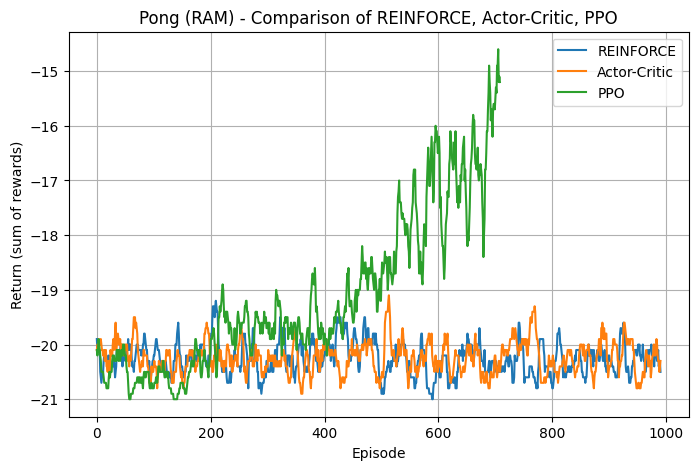

In [ ]:
reinforce_returns = train_reinforce_pong(num_episodes=1000, gamma=0.99, lr=1e-4, render=False)
ac_returns = train_actor_critic_pong(
    num_episodes=1000,
    gamma=0.99,
    lr=1e-4,
    value_coef=0.5,
    entropy_coef=0.01,
    render=False,
)
ppo_returns = train_ppo_pong(
    total_timesteps=1000000,
    rollout_steps=2048,
    minibatch_size=256,
    update_epochs=10,
    gamma=0.99,
    lam=0.95,
    lr=1e-4,
    clip_range=0.2,
    value_coef=0.5,
    entropy_coef=0.01,
    render=False
)

returns_dict = {
    "REINFORCE": reinforce_returns,
    "Actor-Critic": ac_returns,
    "PPO": ppo_returns
}

plot_returns(returns_dict, title="Pong (RAM) - Comparison of REINFORCE, Actor-Critic, PPO")
# Training will take some time.


## 2. Pendulum-v1 and DDPG

Unlike the discrete action space in Atari Pong, **DDPG (Deep Deterministic Policy Gradient)** is specifically designed for **continuous action spaces**. The algorithms we used earlier (REINFORCE, Actor-Critic, PPO) work with discrete actions by sampling from a categorical distribution. However, DDPG uses a deterministic policy that directly outputs continuous action values, making it suitable for environments like Pendulum-v1 where actions are continuous.

### Environment: Pendulum-v1

The **Pendulum-v1** environment is a classic continuous-control benchmark:

- A pendulum is attached to a fixed pivot and can swing freely.
- The agent applies a continuous torque to the pendulum.
- The goal is to swing the pendulum up and keep it upright.
- Observation: 3-dimensional vector `[cos(theta), sin(theta), theta_dot]`.
- Action: 1-dimensional continuous torque in a bounded range (e.g., [-2, 2]).

Rewards are typically **negative** and penalize:
- Deviation from the upright position.
- Angular velocity.
- Magnitude of the control input.



In [ ]:
def make_pendulum_env():
    env = gym.make("Pendulum-v1")
    return env

env_p = make_pendulum_env()
print("Pendulum observation space:", env_p.observation_space)
print("Pendulum action space:", env_p.action_space)
env_p.close()


Pendulum observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Pendulum action space: Box(-2.0, 2.0, (1,), float32)


In [ ]:
class DDPGActor(nn.Module):
    def __init__(self, obs_dim, act_dim, max_action, hidden_sizes=(256, 256)):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_sizes[0]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[1], act_dim),
        )
        self.max_action = max_action

    def forward(self, x):
        x = self.net(x)
        return self.max_action * torch.tanh(x)


class DDPGCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes=(256, 256)):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden_sizes[0]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[1], 1),
        )

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        q = self.net(x)
        return q.squeeze(-1)


In [ ]:
Transition = namedtuple(
    "Transition", ["state", "action", "reward", "next_state", "done"]
)

class ReplayBuffer:
    def __init__(self, capacity=int(1e6)):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(
            Transition(state, action, reward, next_state, done)
        )

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states = torch.as_tensor(
            np.array([t.state for t in batch], dtype=np.float32),
            device=device
        )
        actions = torch.as_tensor(
            np.array([t.action for t in batch], dtype=np.float32),
            device=device
        )
        rewards = torch.as_tensor(
            np.array([t.reward for t in batch], dtype=np.float32),
            device=device
        )
        next_states = torch.as_tensor(
            np.array([t.next_state for t in batch], dtype=np.float32),
            device=device
        )
        dones = torch.as_tensor(
            np.array([t.done for t in batch], dtype=np.float32),
            device=device
        )
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


In [ ]:
def train_ddpg_pendulum(
    num_episodes=200,
    max_steps_per_episode=200,
    gamma=0.99,
    tau=0.005,
    actor_lr=1e-3,
    critic_lr=1e-3,
    batch_size=64,
    replay_size=int(1e6),
    start_timesteps=1000,
    exploration_noise=0.1,
    render=False
):
    env = make_pendulum_env()
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    max_action = float(env.action_space.high[0])

    actor = DDPGActor(obs_dim, act_dim, max_action).to(device)
    critic = DDPGCritic(obs_dim, act_dim).to(device)
    actor_target = DDPGActor(obs_dim, act_dim, max_action).to(device)
    critic_target = DDPGCritic(obs_dim, act_dim).to(device)

    actor_target.load_state_dict(actor.state_dict())
    critic_target.load_state_dict(critic.state_dict())

    actor_optimizer = optim.Adam(actor.parameters(), lr=actor_lr)
    critic_optimizer = optim.Adam(critic.parameters(), lr=critic_lr)

    replay_buffer = ReplayBuffer(capacity=replay_size)

    total_steps = 0
    episode_returns = []

    for episode in range(num_episodes):
        state, info = env.reset()
        ep_return = 0.0

        for step in range(max_steps_per_episode):
            if render:
                env.render()

            state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device)

            if total_steps < start_timesteps:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    action = actor(state_tensor.unsqueeze(0)).cpu().numpy()[0]
                action = action + np.random.normal(0, exploration_noise, size=act_dim)
                action = np.clip(action, -max_action, max_action)

            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            replay_buffer.push(state, action, reward, next_state, float(done))

            state = next_state
            ep_return += reward
            total_steps += 1

            if len(replay_buffer) >= batch_size:
                states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

                # TODO your code
                # |‾‾‾‾‾‾‾‾‾|
                # Critic update: calculate target_values and critic_loss
                with torch.no_grad():
                    next_actions = actor_target(next_states)
                    target_q = critic_target(next_states, next_actions)
                    target_values = rewards + gamma * (1 - dones) * target_q

                current_q = critic(states, actions)
                critic_loss = torch.mean((current_q - target_values) ** 2)
                # |_________|

                critic_optimizer.zero_grad()
                critic_loss.backward()
                critic_optimizer.step()

                # TODO your code
                # |‾‾‾‾‾‾‾‾‾|
                # Actor update: calculate actor_loss
                actor_loss = -critic(states, actor(states)).mean()
                # |_________|

                actor_optimizer.zero_grad()
                actor_loss.backward()
                actor_optimizer.step()

                with torch.no_grad():
                    for param, target_param in zip(critic.parameters(), critic_target.parameters()):
                        target_param.data.mul_(1.0 - tau)
                        target_param.data.add_(tau * param.data)

                    for param, target_param in zip(actor.parameters(), actor_target.parameters()):
                        target_param.data.mul_(1.0 - tau)
                        target_param.data.add_(tau * param.data)

            if done:
                break

        episode_returns.append(ep_return)

        if (episode + 1) % 10 == 0:
            print(f"[DDPG] Episode {episode + 1}/{num_episodes} | Return: {ep_return:.2f}")

    env.close()
    return episode_returns


[DDPG] Episode 10/100 | Return: -1240.03
[DDPG] Episode 20/100 | Return: -1494.84
[DDPG] Episode 30/100 | Return: -363.78
[DDPG] Episode 40/100 | Return: -124.47
[DDPG] Episode 50/100 | Return: -122.53
[DDPG] Episode 60/100 | Return: -122.90
[DDPG] Episode 70/100 | Return: -123.66
[DDPG] Episode 80/100 | Return: -237.24
[DDPG] Episode 90/100 | Return: -249.72
[DDPG] Episode 100/100 | Return: -234.99


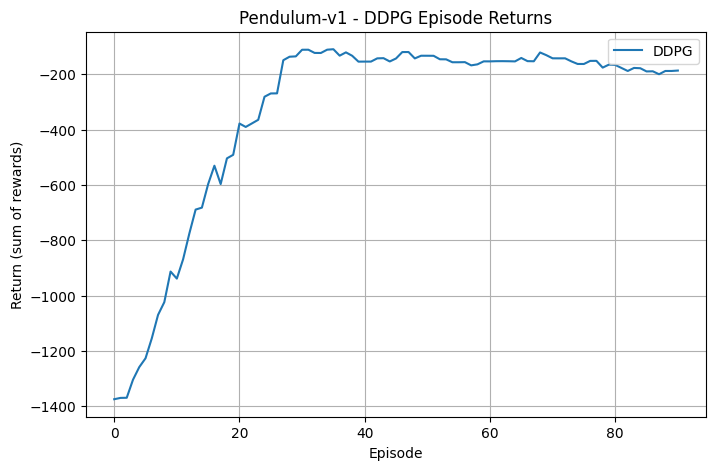

In [ ]:
ddpg_returns = train_ddpg_pendulum(
    num_episodes=100,
    max_steps_per_episode=200,
    gamma=0.99,
    tau=0.005,
    actor_lr=1e-3,
    critic_lr=1e-3,
    batch_size=64,
    start_timesteps=500,
    exploration_noise=0.1,
    render=False
)

plot_returns({"DDPG": ddpg_returns}, title="Pendulum-v1 - DDPG Episode Returns")
